<a href="https://colab.research.google.com/github/darinddv/chromatin_potential/blob/main/notebooks/partC_k2_reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part C acceptance test: reproduce k2 (saddle 2.087) through the machinery

Closes the loop: **Part A** (`Model`) emits the coupling matrix, **Part C**
(`Simulator`) simulates it, and together they must reproduce the completed
k2 result (saddle **2.087**) that was originally produced by the ad-hoc notebook
runner.

Runs locally on CUDA (RTX A3000). Two tiers:
1. **Structural** (needs only the bead file): does k2 -> a sensible
   compartmentalized saddle (>2, clean A/B checkerboard)? Proves the loop closes.
2. **Exact** (this is the faithful reproduction): saddle ~ 2.087 +/- replica noise,
   using the same hg38 bead file and 7x7 k2 potential as the original run.

Local paths assume the repo root with `./data/` holding the bead files.

## 0. Setup + editable-install reload

In [12]:
from google.colab import drive
!git clone -q https://github.com/darinddv/chromatin_potential.git
!pip install -q "openmm[cuda12]" OpenMiChroM cooler cooltools
import sys; sys.path.insert(0, '/content/chromatin_potential/src')
drive.mount('/content/drive')
from chromatin_potential.model import Model, _A_FULL, _L_FULL
from chromatin_potential.simulator import Simulator, BackgroundStack, observed_over_expected, saddle_strength
print('setup OK')

fatal: destination path 'chromatin_potential' already exists and is not an empty directory.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 17.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.3/109.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 95.3 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
setup OK


In [14]:
import os, numpy as np
from collections import Counter

DATA = '/content/drive/MyDrive/uky_cheng/tecsas_ablation'
OUT  = f'{DATA}/partC_k2'          # where per-replica maps + the .ff go
os.makedirs(OUT, exist_ok=True)
from chromatin_potential.model import Model, _A_FULL, _L_FULL
SEQ_HG38 = f'{DATA}/chr10_beads_hg38.txt'   # labels in column 2; the 2.087 run used this
assert os.path.exists(SEQ_HG38), SEQ_HG38
print('data paths OK')

data paths OK


## 1. Bead labels + A/B masks

In [15]:
labels = np.array([l.split()[1] for l in open(SEQ_HG38) if l.strip()])
Nb = len(labels)
isA = np.isin(labels, ['A1','A2'])
isB = np.isin(labels, ['B1','B2','B3','B4'])
print(f'{Nb} beads   A {isA.sum()} ({isA.mean():.1%})   '
      f'B {isB.sum()} ({isB.mean():.1%})   other {(~isA&~isB).sum()}')
print('label counts:', dict(Counter(labels)))
# expect ~2676 beads (hg38) if this reproduces the 2.087 run exactly

2676 beads   A 915 (34.2%)   B 1629 (60.9%)   other 132
label counts: {np.str_('NA'): 132, np.str_('B1'): 353, np.str_('A1'): 230, np.str_('B2'): 654, np.str_('A2'): 685, np.str_('B3'): 622}


## 2. Build the k2 potential via the Model (Part A), expand to 7x7

`Model.from_type_matrix(k=2)` gives the rank-2 5x5 block over A1,A2,B1,B2,B3.
The validated `.ff` is 7x7: B4 copies B3, NA keeps its ORIGINAL couplings
(same expansion as the decomposition notebook cell 16). We rebuild it from the
Model and confirm it matches the shipped `k2_potential.ff` if present.

In [16]:
# rank-2 5x5 block from the Model
m5 = Model.from_type_matrix(_A_FULL, _L_FULL, real_types=[0,1,2,3,4], k=2)
A_k2 = m5.coupling_matrix()                      # 5x5, == notebook A_k2

# expand to 7x7 native format: B4<-B3, NA keeps original row/col
full = _A_FULL.copy()
full[np.ix_([0,1,2,3,4],[0,1,2,3,4])] = A_k2
full[5,:5] = A_k2[4,:]; full[:5,5] = A_k2[:,4]; full[5,5] = A_k2[4,4]   # B4<-B3

ff_path = f'{OUT}/k2_from_model.ff'
with open(ff_path,'w') as f:
    f.write(','.join(_L_FULL)+'\n')
    for a in range(7):
        f.write(','.join(f'{full[a,b]:.6E}' for b in range(7))+'\n')
print('wrote', ff_path)
print(open(ff_path).read())

# optional: confirm it matches a shipped k2_potential.ff if you have one in ./data
shipped = f'{DATA}/k2_potential.ff'
if os.path.exists(shipped):
    a = open(shipped).read().split('\n',1)[1]
    b = open(ff_path).read().split('\n',1)[1]
    va = np.array([[float(x) for x in r.split(',')] for r in a.strip().split('\n')])
    vb = np.array([[float(x) for x in r.split(',')] for r in b.strip().split('\n')])
    print('max diff vs shipped k2_potential.ff:', np.abs(va-vb).max())

wrote /content/drive/MyDrive/uky_cheng/tecsas_ablation/partC_k2/k2_from_model.ff
A1,A2,B1,B2,B3,B4,NA
-2.674359E-01,-2.775305E-01,-2.610730E-01,-2.583572E-01,-2.692202E-01,-2.692202E-01,-2.260000E-01
-2.775305E-01,-2.875171E-01,-2.899142E-01,-2.872863E-01,-2.938115E-01,-2.938115E-01,-2.450000E-01
-2.610730E-01,-2.899142E-01,-3.351792E-01,-3.277104E-01,-3.378895E-01,-3.378895E-01,-2.100000E-01
-2.583572E-01,-2.872863E-01,-3.277104E-01,-3.202033E-01,-3.315386E-01,-3.315386E-01,-2.830000E-01
-2.692202E-01,-2.938115E-01,-3.378895E-01,-3.315386E-01,-3.389784E-01,-3.389784E-01,-3.490000E-01
-2.692202E-01,-2.938115E-01,-3.378895E-01,-3.315386E-01,-3.389784E-01,-3.389784E-01,-3.490000E-01
-2.260000E-01,-2.450000E-01,-2.100000E-01,-2.830000E-01,-3.490000E-01,-3.490000E-01,-2.560000E-01

max diff vs shipped k2_potential.ff: 0.0


## 3. Smoke test: ONE replica

Run a single replica first. This catches any local/Windows issue (file handles,
CUDA, cndb read, convergence metric) before committing to 20 runs.
Watch for: the three phases running, a `.cndb` produced, and a printed
convergence value (first/second-half map correlation; want > ~0.9).

In [ ]:
sim = Simulator(seq_file=SEQ_HG38, out_dir=OUT, platform='cuda',
                background=BackgroundStack())   # validated WCA+IC+confinement stack

P0 = sim.run_replica('k2', 0, ff_path, verbose=True)
print('smoke-test replica done; map shape:',
      None if P0 is None else P0.shape)

    ***************************************************************************************     
     **** **** *** *** *** *** *** *** OpenMiChroM-1.1.1 *** *** *** *** *** *** **** ****      

         OpenMiChroM is a Python library for performing chromatin dynamics simulations.         
                            OpenMiChroM uses the OpenMM Python API,                             
                employing the MiChroM (Minimal Chromatin Model) energy function.                
      The chromatin dynamics simulations generate an ensemble of 3D chromosomal structures      
      that are consistent with experimental Hi-C maps, also allows simulations of a single      
                 or multiple chromosome chain using High-Performance Computing                  
                            in different platforms (GPUs and CPUs).                             

         OpenMiChroM documentation is available at https://open-michrom.readthedocs.io          

         OpenMiChroM is des

KeyboardInterrupt: 

In [ ]:
print("PLATFORM:", sim.simulation.context.getPlatform().getName(), flush=True)

AttributeError: 'Simulator' object has no attribute 'simulation'

## 4. Full ensemble: 20 replicas (resumable)

Skips any replica whose map already exists, so you can re-run this cell after an
interruption. ~3 min/replica on the A3000 was the Colab figure; local may differ.

In [17]:
pooled = sim.run_ensemble('k2', ff_path, n_replicas=20, verbose=True)
print('pooled map shape:', pooled.shape)

skip k2_rep0
--- k2 seed 0 done, 0.0 min
skip k2_rep1
--- k2 seed 1 done, 0.0 min
skip k2_rep2
--- k2 seed 2 done, 0.0 min
skip k2_rep3
--- k2 seed 3 done, 0.0 min
skip k2_rep4
--- k2 seed 4 done, 0.0 min
skip k2_rep5
--- k2 seed 5 done, 0.0 min
skip k2_rep6
--- k2 seed 6 done, 0.0 min
skip k2_rep7
--- k2 seed 7 done, 0.0 min
skip k2_rep8
--- k2 seed 8 done, 0.0 min
skip k2_rep9
--- k2 seed 9 done, 0.0 min
skip k2_rep10
--- k2 seed 10 done, 0.0 min
skip k2_rep11
--- k2 seed 11 done, 0.0 min
skip k2_rep12
--- k2 seed 12 done, 0.0 min
skip k2_rep13
--- k2 seed 13 done, 0.0 min
skip k2_rep14
--- k2 seed 14 done, 0.0 min
skip k2_rep15
--- k2 seed 15 done, 0.0 min
skip k2_rep16
--- k2 seed 16 done, 0.0 min
skip k2_rep17
--- k2 seed 17 done, 0.0 min
skip k2_rep18
--- k2 seed 18 done, 0.0 min
skip k2_rep19
--- k2 seed 19 done, 0.0 min
pooled map shape: (2676, 2676)


## 5. The acceptance check: saddle must reproduce 2.087

In [18]:
OE = observed_over_expected(pooled)
s  = saddle_strength(OE, isA, isB)
print(f'k2-via-machinery saddle = {s:.3f}')
print(f'target (completed k2 result) = 2.087')
print(f'difference = {s-2.087:+.3f}')

tol = 0.15   # replica-noise band; the original ablation bootstrap CI was ~this wide
if abs(s-2.087) < tol:
    print('\nPASS: machinery reproduces the k2 result within replica noise.')
    print('Part A + Part C are validated end-to-end.')
else:
    print('\nCHECK: saddle outside tolerance. Investigate before proceeding.')
    print('  - hg38 bead file? (2676 beads)')
    print('  - convergence values on the replicas (see maps/*.conv.npy)?')
    print('  - platform/protocol identical to the original run?')

k2-via-machinery saddle = 2.073
target (completed k2 result) = 2.087
difference = -0.014

PASS: machinery reproduces the k2 result within replica noise.
Part A + Part C are validated end-to-end.


### 5a. Convergence report

Every replica saved its first/second-half map correlation. All should be high;
any low ones are flagged and would explain a saddle discrepancy.

In [19]:
import glob
convs = []
for f in sorted(glob.glob(f'{OUT}/maps/k2_rep*.conv.npy')):
    convs.append((os.path.basename(f), float(np.load(f)[0])))
for name, c in convs:
    flag = '' if c >= 0.9 else '  <-- LOW'
    print(f'{name}: {c:.3f}{flag}')
print(f'\nmedian convergence: {np.median([c for _,c in convs]):.3f}')

k2_rep0.conv.npy: 0.947
k2_rep1.conv.npy: 0.944
k2_rep10.conv.npy: 0.950
k2_rep11.conv.npy: 0.941
k2_rep12.conv.npy: 0.941
k2_rep13.conv.npy: 0.946
k2_rep14.conv.npy: 0.948
k2_rep15.conv.npy: 0.945
k2_rep16.conv.npy: 0.947
k2_rep17.conv.npy: 0.944
k2_rep18.conv.npy: 0.946
k2_rep19.conv.npy: 0.948
k2_rep2.conv.npy: 0.948
k2_rep3.conv.npy: 0.951
k2_rep4.conv.npy: 0.950
k2_rep5.conv.npy: 0.948
k2_rep6.conv.npy: 0.941
k2_rep7.conv.npy: 0.951
k2_rep8.conv.npy: 0.948
k2_rep9.conv.npy: 0.950

median convergence: 0.947


### 5b. Visual check: the O/E saddle plot

Bins ranked by experimental PC1; a clean red/blue checkerboard = compartments
formed correctly. (Optional; needs the experimental map for the PC1 ranking, so
here we rank by A/B label instead as a simpler standin.)

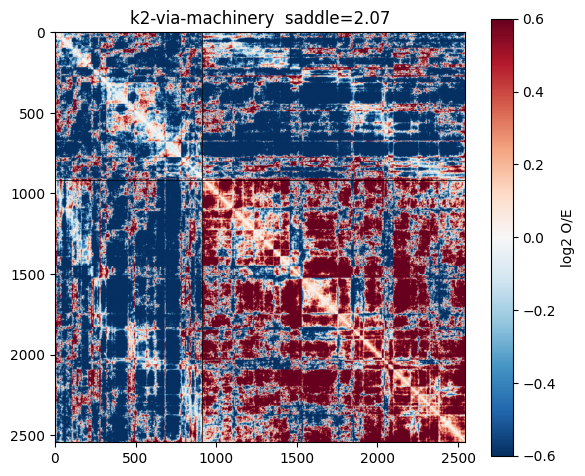

In [20]:
import matplotlib.pyplot as plt
# simple ordering: A beads first, then B, to show the block structure
order = np.concatenate([np.where(isA)[0], np.where(isB)[0]])
sub = OE[np.ix_(order, order)]
with np.errstate(divide='ignore', invalid='ignore'):
    plt.figure(figsize=(6,5))
    plt.imshow(np.log2(sub), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar(label='log2 O/E')
    plt.title(f'k2-via-machinery  saddle={s:.2f}')
    plt.axhline(isA.sum(), c='k', lw=0.5); plt.axvline(isA.sum(), c='k', lw=0.5)
    plt.tight_layout(); plt.show()

## 6. What this proves

If the saddle reproduces 2.087:
- The `Model` object emits the correct coupling matrix (already proven at machine
  precision in the k2 self-test, now confirmed dynamically).
- The `Simulator` wrapper runs the validated protocol faithfully on local CUDA.
- The convergence gate works.
- **Part A + Part C are a working forward path.** Next: the optimizer (fit Lambda
  for a fixed C), then self-recovery validation on a small polymer.

If it does NOT reproduce: the machinery differs from the original runner
somewhere. The convergence report (5a) and the bead-count check (1) are the first
suspects.